# Seq2Seq Text Summarization with Bahdanau Attention (Pure NumPy)

Educational implementation on the BBC News Summary dataset. Every part of the
model — embeddings, GRU cells, Bahdanau attention, output projection — is
implemented with hand-derived forward **and** backward (backprop) passes in
NumPy. No PyTorch/TensorFlow/autodiff is used for the model itself.

Because there is no autodiff and no batched BPTT, training runs **one example
at a time** (batch size 1) with plain Python loops over time steps. Hyperparameters
below are deliberately modest so the whole notebook runs in a reasonable time on CPU;
scale them up once you've confirmed the mechanics work.

In [4]:
import os
import re
import pickle
import random
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
random.seed(42)

## 1. Data acquisition

Downloads the "BBC News Summary" dataset via `kagglehub`. It unpacks into
`News Articles/<category>/*.txt` and `Summaries/<category>/*.txt` for 5
categories (business, entertainment, politics, sport, tech).

In [5]:
import kagglehub

dataset_path = kagglehub.dataset_download("pariza/bbc-news-summary")
print("Dataset downloaded to:", dataset_path)

/home/habib/Desktop/Eighth_semester/.venv-1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 8.91M/8.91M [00:02<00:00, 4.32MB/s]

Extracting files...


Dataset downloaded to: /home/habib/.cache/kagglehub/datasets/pariza/bbc-news-summary/versions/2


In [6]:
def load_bbc_pairs(dataset_path):
    candidates = [
        (os.path.join(dataset_path, "BBC News Summary", "News Articles"),
         os.path.join(dataset_path, "BBC News Summary", "Summaries")),
        (os.path.join(dataset_path, "News Articles"),
         os.path.join(dataset_path, "Summaries")),
    ]
    articles_dir, summaries_dir = next(
        (a, s) for a, s in candidates if os.path.isdir(a)
    )

    pairs = []
    for category in sorted(os.listdir(articles_dir)):
        art_cat_dir = os.path.join(articles_dir, category)
        sum_cat_dir = os.path.join(summaries_dir, category)
        if not os.path.isdir(art_cat_dir):
            continue
        for fname in sorted(os.listdir(art_cat_dir)):
            art_path = os.path.join(art_cat_dir, fname)
            sum_path = os.path.join(sum_cat_dir, fname)
            if not os.path.isfile(sum_path):
                continue
            with open(art_path, "r", encoding="latin-1") as f:
                article = f.read()
            with open(sum_path, "r", encoding="latin-1") as f:
                summary = f.read()
            pairs.append((article, summary))
    return pairs

pairs = load_bbc_pairs(dataset_path)
print("Loaded", len(pairs), "article/summary pairs")
print(pairs[0][0][:300])
print("---SUMMARY---")
print(pairs[0][1][:300])

Loaded 2225 article/summary pairs
Ad sales boost Time Warner profit

Quarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (Â£600m) for the three months to December, from $639m year-earlier.

The firm, which is now one of the biggest investors in Google, benefited from sales of high-speed internet connections and high
---SUMMARY---
TimeWarner said fourth quarter sales rose 2% to $11.1bn from $10.9bn.For the full-year, TimeWarner posted a profit of $3.36bn, up 27% from its 2003 performance, while revenues grew 6.4% to $42.09bn.Quarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (Â£600m) for the three months to 


## 2. Preprocessing

Cleaning, tokenizing, vocabulary building, and converting to id sequences.
Since we train one example at a time (no batching), sequences are simply
**truncated** to a max length — no padding is needed.

In [7]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s\.]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize(text):
    return clean_text(text).split()

VOCAB_SIZE = 6000
EMBED_DIM = 64
HIDDEN_SIZE = 96
MAX_ARTICLE_LEN = 150
MAX_SUMMARY_LEN = 30
MAX_EXAMPLES = 120

PAD, SOS, EOS, UNK = 0, 1, 2, 3

In [8]:
counter = Counter()
tokenized_pairs = []
for article, summary in pairs:
    art_tokens = tokenize(article)
    sum_tokens = tokenize(summary)
    tokenized_pairs.append((art_tokens, sum_tokens))
    counter.update(art_tokens)
    counter.update(sum_tokens)

most_common = counter.most_common(VOCAB_SIZE - 4)
word2idx = {"<pad>": PAD, "<sos>": SOS, "<eos>": EOS, "<unk>": UNK}
for word, _ in most_common:
    word2idx[word] = len(word2idx)
idx2word = {i: w for w, i in word2idx.items()}
VOCAB_SIZE = len(word2idx)
print("Vocab size:", VOCAB_SIZE)

Vocab size: 6000


In [9]:
def to_ids(tokens, word2idx, max_len):
    return [word2idx.get(t, UNK) for t in tokens[:max_len]]

data = []
for art_tokens, sum_tokens in tokenized_pairs:
    art_ids = to_ids(art_tokens, word2idx, MAX_ARTICLE_LEN)
    sum_ids = [SOS] + to_ids(sum_tokens, word2idx, MAX_SUMMARY_LEN - 2) + [EOS]
    if len(art_ids) < 2 or len(sum_ids) < 3:
        continue
    data.append((art_ids, sum_ids))

random.shuffle(data)
data = data[:MAX_EXAMPLES]
split = int(0.9 * len(data))
train_data, val_data = data[:split], data[split:]
print(len(train_data), "train,", len(val_data), "val")

108 train, 12 val


## 3. Model components (NumPy,forward + backward)

### Math helpers

In [10]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def softmax(x):
    x = x - np.max(x)
    e = np.exp(x)
    return e / np.sum(e)

### Parameter initialization

Sizes are inferred from the passed-in `vocab_size` / `embed_dim` / `hidden_size`
arguments (not module-level globals) so the same functions can be reused for a
tiny toy example in the gradient check below.

In [11]:
def init_params(vocab_size, embed_dim, hidden_size):
    def rnd(*shape):
        return np.random.randn(*shape) * 0.05

    p = {"Emb": rnd(vocab_size, embed_dim)}

    for gate in ["z", "r", "h"]:
        p[f"enc_W{gate}"] = rnd(hidden_size, embed_dim)
        p[f"enc_U{gate}"] = rnd(hidden_size, hidden_size)
        p[f"enc_b{gate}"] = np.zeros(hidden_size)

    dec_in = embed_dim + hidden_size
    for gate in ["z", "r", "h"]:
        p[f"dec_W{gate}"] = rnd(hidden_size, dec_in)
        p[f"dec_U{gate}"] = rnd(hidden_size, hidden_size)
        p[f"dec_b{gate}"] = np.zeros(hidden_size)

    p["Wa"] = rnd(hidden_size, hidden_size)
    p["Ua"] = rnd(hidden_size, hidden_size)
    p["v"] = rnd(hidden_size)

    p["Wo"] = rnd(vocab_size, hidden_size * 2)
    p["bo"] = np.zeros(vocab_size)

    return p

def zero_grads(params):
    return {k: np.zeros_like(v) for k, v in params.items()}

### GRU cell (forward + backward)

`z_t = sigmoid(Wz x_t + Uz h_{t-1} + bz)`, `r_t = sigmoid(Wr x_t + Ur h_{t-1} + br)`,
`h~_t = tanh(Wh x_t + Uh (r_t * h_{t-1}) + bh)`, `h_t = (1-z_t) h_{t-1} + z_t h~_t`.
Encoder and decoder each use their own weights, selected via `prefix` ("enc"/"dec").

In [12]:
def gru_forward(x, h_prev, p, prefix):
    Wz, Uz, bz = p[f"{prefix}_Wz"], p[f"{prefix}_Uz"], p[f"{prefix}_bz"]
    Wr, Ur, br = p[f"{prefix}_Wr"], p[f"{prefix}_Ur"], p[f"{prefix}_br"]
    Wh, Uh, bh = p[f"{prefix}_Wh"], p[f"{prefix}_Uh"], p[f"{prefix}_bh"]

    z = sigmoid(Wz @ x + Uz @ h_prev + bz)
    r = sigmoid(Wr @ x + Ur @ h_prev + br)
    hh = np.tanh(Wh @ x + Uh @ (r * h_prev) + bh)
    h = (1 - z) * h_prev + z * hh

    cache = (x, h_prev, z, r, hh, h)
    return h, cache


def gru_backward(dh, cache, p, prefix):
    x, h_prev, z, r, hh, h = cache
    Wz, Uz = p[f"{prefix}_Wz"], p[f"{prefix}_Uz"]
    Wr, Ur = p[f"{prefix}_Wr"], p[f"{prefix}_Ur"]
    Wh, Uh = p[f"{prefix}_Wh"], p[f"{prefix}_Uh"]

    grads = {}

    dz = dh * (hh - h_prev)
    dhh = dh * z
    dh_prev = dh * (1 - z)

    dhh_pre = dhh * (1 - hh ** 2)
    grads[f"{prefix}_Wh"] = np.outer(dhh_pre, x)
    grads[f"{prefix}_Uh"] = np.outer(dhh_pre, r * h_prev)
    grads[f"{prefix}_bh"] = dhh_pre
    d_r_hprev = Uh.T @ dhh_pre
    dr = d_r_hprev * h_prev
    dh_prev = dh_prev + d_r_hprev * r
    dx = Wh.T @ dhh_pre

    dz_pre = dz * z * (1 - z)
    grads[f"{prefix}_Wz"] = np.outer(dz_pre, x)
    grads[f"{prefix}_Uz"] = np.outer(dz_pre, h_prev)
    grads[f"{prefix}_bz"] = dz_pre
    dx = dx + Wz.T @ dz_pre
    dh_prev = dh_prev + Uz.T @ dz_pre

    dr_pre = dr * r * (1 - r)
    grads[f"{prefix}_Wr"] = np.outer(dr_pre, x)
    grads[f"{prefix}_Ur"] = np.outer(dr_pre, h_prev)
    grads[f"{prefix}_br"] = dr_pre
    dx = dx + Wr.T @ dr_pre
    dh_prev = dh_prev + Ur.T @ dr_pre

    return dx, dh_prev, grads

### Encoder

Runs the encoder GRU cell over the (unpadded, truncated) article token ids,
keeping every hidden state (needed by attention) plus per-step caches (needed
by the encoder's own backward BPTT pass).

In [13]:
def encoder_forward(article_ids, p):
    H = p["enc_Wz"].shape[0]
    h = np.zeros(H)
    H_enc = np.zeros((len(article_ids), H))
    caches = []
    for t, tok in enumerate(article_ids):
        x = p["Emb"][tok]
        h, cache = gru_forward(x, h, p, "enc")
        H_enc[t] = h
        caches.append((tok, cache))
    return H_enc, caches

### Bahdanau (additive) attention

`score_i = v . tanh(Wa @ s_{t-1} + Ua @ h_enc_i)`, `alpha = softmax(score)`,
`context_t = sum_i alpha_i * h_enc_i`.

In [14]:
def attention_forward(s_prev, H_enc, p):
    Wa, Ua, v = p["Wa"], p["Ua"], p["v"]
    Wa_s = Wa @ s_prev                        # (H,)
    U_h = H_enc @ Ua.T                        # (Tx, H)
    tanh_val = np.tanh(Wa_s[None, :] + U_h)   # (Tx, H)
    scores = tanh_val @ v                     # (Tx,)
    alpha = softmax(scores)                   # (Tx,)
    context = alpha @ H_enc                   # (H,)
    cache = (s_prev, H_enc, tanh_val, alpha)
    return context, alpha, cache


def attention_backward(dcontext, cache, p):
    s_prev, H_enc, tanh_val, alpha = cache
    Wa, Ua, v = p["Wa"], p["Ua"], p["v"]

    grads = {}
    dalpha = H_enc @ dcontext                       # (Tx,)
    dH_enc = np.outer(alpha, dcontext)              # (Tx, H) via context path

    dscores = alpha * (dalpha - np.sum(alpha * dalpha))  # softmax backward

    dtanh_val = np.outer(dscores, v)                # (Tx, H)
    grads["v"] = tanh_val.T @ dscores               # (H,)

    dtanh_arg = dtanh_val * (1 - tanh_val ** 2)      # (Tx, H)

    dWa_s = dtanh_arg.sum(axis=0)                   # (H,)
    dU_h = dtanh_arg                                # (Tx, H)

    grads["Wa"] = np.outer(dWa_s, s_prev)
    ds_prev = Wa.T @ dWa_s

    grads["Ua"] = dU_h.T @ H_enc
    dH_enc = dH_enc + dU_h @ Ua

    return ds_prev, dH_enc, grads

## 4. Full forward / backward pass

`forward` encodes the article, then decodes the summary with teacher forcing,
computing masked (here: unpadded, so unconditional) cross-entropy loss at each
step and caching everything needed for backprop.

`backward` runs BPTT through the decoder timesteps first (accumulating decoder
GRU / attention / output-projection / embedding gradients, and summing the
per-step gradient into the encoder hidden states), then BPTT through the
encoder timesteps.

In [15]:
def forward(article_ids, summary_ids, p):
    H_enc, enc_caches = encoder_forward(article_ids, p)
    E = p["Emb"].shape[1]
    s = H_enc[-1].copy()

    loss = 0.0
    n_tokens = 0
    dec_caches = []

    T = len(summary_ids) - 1
    for t in range(T):
        tok_in = summary_ids[t]
        target = summary_ids[t + 1]

        context, alpha, attn_cache = attention_forward(s, H_enc, p)
        x_in = np.concatenate([p["Emb"][tok_in], context])
        s_new, gru_cache = gru_forward(x_in, s, p, "dec")

        concat_out = np.concatenate([s_new, context])
        logits = p["Wo"] @ concat_out + p["bo"]
        probs = softmax(logits)

        loss += -np.log(probs[target] + 1e-9)
        n_tokens += 1

        dec_caches.append((tok_in, target, attn_cache, gru_cache, concat_out, probs))
        s = s_new

    n_tokens = max(n_tokens, 1)
    loss = loss / n_tokens
    cache = {"H_enc": H_enc, "enc_caches": enc_caches, "dec_caches": dec_caches,
              "n_tokens": n_tokens, "E": E}
    return loss, cache


def backward(cache, p):
    grads = zero_grads(p)
    H_enc = cache["H_enc"]
    Tx, H = H_enc.shape
    E = cache["E"]
    n_tokens = cache["n_tokens"]

    dH_enc_total = np.zeros_like(H_enc)
    dS_next = np.zeros(H)

    for (tok_in, target, attn_cache, gru_cache, concat_out, probs) in reversed(cache["dec_caches"]):
        dlogits = probs.copy()
        dlogits[target] -= 1.0
        dlogits = dlogits / n_tokens

        grads["Wo"] += np.outer(dlogits, concat_out)
        grads["bo"] += dlogits

        dconcat = p["Wo"].T @ dlogits
        ds_from_out = dconcat[:H]
        dcontext = dconcat[H:].copy()

        dS_t = dS_next + ds_from_out

        dx_in, ds_prev_from_gru, gru_grads = gru_backward(dS_t, gru_cache, p, "dec")
        for k, v in gru_grads.items():
            grads[k] += v

        d_emb_in = dx_in[:E]
        dcontext = dcontext + dx_in[E:]

        grads["Emb"][tok_in] += d_emb_in

        ds_prev_from_attn, dH_enc_step, attn_grads = attention_backward(dcontext, attn_cache, p)
        for k, v in attn_grads.items():
            grads[k] += v

        dH_enc_total += dH_enc_step
        dS_next = ds_prev_from_gru + ds_prev_from_attn

    # dS_next now holds the gradient wrt the decoder's initial state,
    # which was initialized from H_enc[-1].
    dH_enc_total[-1] += dS_next

    dh_next = np.zeros(H)
    for t in reversed(range(Tx)):
        tok, enc_cache = cache["enc_caches"][t]
        dh = dH_enc_total[t] + dh_next
        dx, dh_prev, gru_grads = gru_backward(dh, enc_cache, p, "enc")
        for k, v in gru_grads.items():
            grads[k] += v
        grads["Emb"][tok] += dx
        dh_next = dh_prev

    return grads

### Gradient clipping and Adam optimizer

In [16]:
def clip_grads(grads, max_norm=5.0):
    total_norm = np.sqrt(sum(np.sum(g ** 2) for g in grads.values()))
    if total_norm > max_norm:
        scale = max_norm / (total_norm + 1e-9)
        for k in grads:
            grads[k] *= scale
    return grads


class Adam:
    def __init__(self, params, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr, self.beta1, self.beta2, self.eps = lr, beta1, beta2, eps
        self.m = {k: np.zeros_like(v) for k, v in params.items()}
        self.v = {k: np.zeros_like(v) for k, v in params.items()}
        self.t = 0

    def step(self, params, grads):
        self.t += 1
        for k in params:
            self.m[k] = self.beta1 * self.m[k] + (1 - self.beta1) * grads[k]
            self.v[k] = self.beta2 * self.v[k] + (1 - self.beta2) * (grads[k] ** 2)
            m_hat = self.m[k] / (1 - self.beta1 ** self.t)
            v_hat = self.v[k] / (1 - self.beta2 ** self.t)
            params[k] -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)

### Gradient check

Before trusting the hand-derived backward pass, compare it against a numerical
gradient (finite differences) on a tiny toy example. Relative error should be
very small (~1e-6 to 1e-4) for every parameter tested.

In [17]:
def gradient_check():
    toy_p = init_params(vocab_size=6, embed_dim=4, hidden_size=5)
    article_ids = [4, 5, 2]
    summary_ids = [SOS, 4, 5, EOS]

    _, cache = forward(article_ids, summary_ids, toy_p)
    grads = backward(cache, toy_p)

    eps = 1e-5
    for name in ["Wa", "Ua", "v", "dec_Wz", "enc_Uh", "Wo", "Emb"]:
        w = toy_p[name]
        idx = tuple(np.random.randint(0, s) for s in w.shape)
        orig = w[idx]

        w[idx] = orig + eps
        loss_plus, _ = forward(article_ids, summary_ids, toy_p)
        w[idx] = orig - eps
        loss_minus, _ = forward(article_ids, summary_ids, toy_p)
        w[idx] = orig

        numerical = (loss_plus - loss_minus) / (2 * eps)
        analytic = grads[name][idx]
        rel_err = abs(numerical - analytic) / (abs(numerical) + abs(analytic) + 1e-9)
        print(f"{name}{idx}: analytic={analytic: .6f} numerical={numerical: .6f} rel_err={rel_err:.2e}")

gradient_check()

Wa(0, 4): analytic= 0.000000 numerical= 0.000000 rel_err=2.51e-09
Ua(3, 1): analytic=-0.000000 numerical=-0.000000 rel_err=1.83e-04
v(0,): analytic=-0.000000 numerical=-0.000000 rel_err=2.72e-03
dec_Wz(0, 6): analytic=-0.000000 numerical=-0.000000 rel_err=6.13e-05
enc_Uh(1, 3): analytic= 0.000004 numerical= 0.000004 rel_err=3.73e-07
Wo(0, 0): analytic=-0.000032 numerical=-0.000032 rel_err=2.57e-07
Emb(4, 3): analytic=-0.000643 numerical=-0.000643 rel_err=1.38e-08


## 5. Inference (greedy + beam search decoding)

In [18]:
def greedy_decode(article_ids, p, idx2word, max_len):
    H_enc, _ = encoder_forward(article_ids, p)
    s = H_enc[-1].copy()
    tok = SOS
    result = []
    for _ in range(max_len):
        context, alpha, _ = attention_forward(s, H_enc, p)
        x_in = np.concatenate([p["Emb"][tok], context])
        s, _ = gru_forward(x_in, s, p, "dec")
        concat_out = np.concatenate([s, context])
        logits = p["Wo"] @ concat_out + p["bo"]
        tok = int(np.argmax(logits))
        if tok == EOS:
            break
        result.append(tok)
    return " ".join(idx2word.get(t, "<unk>") for t in result)


def beam_search_decode(article_ids, p, idx2word, max_len, beam_width=3):
    H_enc, _ = encoder_forward(article_ids, p)
    s0 = H_enc[-1].copy()
    beams = [(0.0, s0, [SOS])]
    completed = []

    for _ in range(max_len):
        candidates = []
        for score, s, seq in beams:
            if seq[-1] == EOS:
                completed.append((score, seq))
                continue
            context, alpha, _ = attention_forward(s, H_enc, p)
            x_in = np.concatenate([p["Emb"][seq[-1]], context])
            s_new, _ = gru_forward(x_in, s, p, "dec")
            concat_out = np.concatenate([s_new, context])
            logits = p["Wo"] @ concat_out + p["bo"]
            log_probs = np.log(softmax(logits) + 1e-9)
            top_idx = np.argsort(log_probs)[-beam_width:]
            for tok in top_idx:
                candidates.append((score + log_probs[tok], s_new, seq + [int(tok)]))
        candidates.sort(key=lambda b: b[0], reverse=True)
        beams = candidates[:beam_width]
        if not beams:
            break

    completed.extend((score, seq) for score, s, seq in beams)
    completed.sort(key=lambda b: b[0], reverse=True)
    best_seq = completed[0][1] if completed else []
    tokens = [t for t in best_seq if t not in (SOS, EOS)]
    return " ".join(idx2word.get(t, "<unk>") for t in tokens)

## 6. Training loop

Trains on `train_data` one example at a time, with gradient clipping and Adam.
Prints a sample decoded summary periodically so you can watch it improve.

In [19]:
params = init_params(VOCAB_SIZE, EMBED_DIM, HIDDEN_SIZE)
optimizer = Adam(params, lr=1e-3)

EPOCHS = 5
CLIP_NORM = 5.0

history = []
for epoch in range(EPOCHS):
    random.shuffle(train_data)
    epoch_loss = 0.0
    for i, (article_ids, summary_ids) in enumerate(train_data):
        loss, cache = forward(article_ids, summary_ids, params)
        grads = backward(cache, params)
        grads = clip_grads(grads, CLIP_NORM)
        optimizer.step(params, grads)
        epoch_loss += loss

        if i % 20 == 0:
            pred = greedy_decode(article_ids, params, idx2word, MAX_SUMMARY_LEN)
            ref = " ".join(idx2word[t] for t in summary_ids if t not in (SOS, EOS))
            print(f"epoch {epoch} ex {i}: loss={loss:.3f}")
            print("  ref :", ref[:150])
            print("  pred:", pred[:150])

    epoch_loss /= len(train_data)
    history.append(epoch_loss)
    print(f"=== epoch {epoch} avg loss: {epoch_loss:.4f} ===")

with open("params.pkl", "wb") as f:
    pickle.dump(params, f)

epoch 0 ex 0: loss=8.700
  ref : mr clarke says he does not intend to use the house arrest powers now even for the 11 current terror <unk> to allow home secretary charles clarke to
  pred: different earnings 1 provider system biarritz mortgage to sentences mass building limits activity learning net. viewing wake jobs previous services. c
epoch 0 ex 20: loss=8.293
  ref : <unk> has been a strong <unk> to profits in 2004 but gm said it will do less well this year delivering net income of <unk> said it expects
  pred: <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> 
epoch 0 ex 40: loss=6.640
  ref : and mr greenspan warned asian states could soon stop funding the us <unk> mr greenspan said that could turn into a trend if the fall of the dollar
  pred: the the the of of of of of of of of of of of of of of of of of of of of of of of of of of of
epoch 0 ex 60: loss=6.389
  ref : <unk> said m

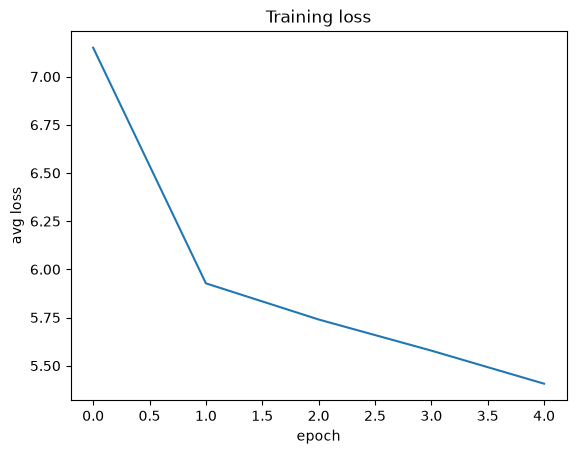

In [20]:
plt.plot(history)
plt.xlabel("epoch")
plt.ylabel("avg loss")
plt.title("Training loss")
plt.show()

## 7. Evaluation (ROUGE-1 / ROUGE-2 / ROUGE-L)

Implemented from scratch in plain Python (n-gram overlap for ROUGE-N, LCS for
ROUGE-L) — no external ROUGE package, consistent with the from-scratch constraint.

In [ ]:
def ngrams(tokens, n):
    return [tuple(tokens[i:i + n]) for i in range(len(tokens) - n + 1)]


def rouge_n(ref_tokens, hyp_tokens, n):
    ref_ngrams = Counter(ngrams(ref_tokens, n))
    hyp_ngrams = Counter(ngrams(hyp_tokens, n))
    overlap = sum((ref_ngrams & hyp_ngrams).values())
    if sum(hyp_ngrams.values()) == 0 or sum(ref_ngrams.values()) == 0:
        return 0.0, 0.0, 0.0
    recall = overlap / sum(ref_ngrams.values())
    precision = overlap / sum(hyp_ngrams.values())
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    return precision, recall, f1


def lcs_len(a, b):
    dp = np.zeros((len(a) + 1, len(b) + 1), dtype=int)
    for i in range(1, len(a) + 1):
        for j in range(1, len(b) + 1):
            if a[i - 1] == b[j - 1]:
                dp[i][j] = dp[i - 1][j - 1] + 1
            else:
                dp[i][j] = max(dp[i - 1][j], dp[i][j - 1])
    return dp[len(a)][len(b)]


def rouge_l(ref_tokens, hyp_tokens):
    if len(ref_tokens) == 0 or len(hyp_tokens) == 0:
        return 0.0, 0.0, 0.0
    lcs = lcs_len(ref_tokens, hyp_tokens)
    recall = lcs / len(ref_tokens)
    precision = lcs / len(hyp_tokens)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    return precision, recall, f1

In [ ]:
r1_scores, r2_scores, rl_scores = [], [], []
for article_ids, summary_ids in val_data:
    pred = greedy_decode(article_ids, params, idx2word, MAX_SUMMARY_LEN)
    ref = " ".join(idx2word[t] for t in summary_ids if t not in (SOS, EOS))

    hyp_tokens, ref_tokens = pred.split(), ref.split()

    _, _, f1_1 = rouge_n(ref_tokens, hyp_tokens, 1)
    _, _, f1_2 = rouge_n(ref_tokens, hyp_tokens, 2)
    _, _, f1_l = rouge_l(ref_tokens, hyp_tokens)

    r1_scores.append(f1_1)
    r2_scores.append(f1_2)
    rl_scores.append(f1_l)

print("ROUGE-1 F1:", np.mean(r1_scores) if r1_scores else float("nan"))
print("ROUGE-2 F1:", np.mean(r2_scores) if r2_scores else float("nan"))
print("ROUGE-L F1:", np.mean(rl_scores) if rl_scores else float("nan"))

In [ ]:
for article_ids, summary_ids in val_data[:5]:
    article_text = " ".join(idx2word[t] for t in article_ids)
    ref = " ".join(idx2word[t] for t in summary_ids if t not in (SOS, EOS))
    pred_greedy = greedy_decode(article_ids, params, idx2word, MAX_SUMMARY_LEN)
    pred_beam = beam_search_decode(article_ids, params, idx2word, MAX_SUMMARY_LEN)
    print("ARTICLE     :", article_text[:200], "...")
    print("REFERENCE   :", ref)
    print("GREEDY PRED :", pred_greedy)
    print("BEAM PRED   :", pred_beam)
    print("-" * 80)